# Evaluating GenAI models: autoencoder vs GAN on MNIST

Practice activity from Microsoft *Foundations of AI and Machine Learning* - Module: Evaluating GenAI Models.

Two generative models, two very different evaluation regimes:

| Model | Goal | Metric |
|---|---|---|
| Autoencoder | Reconstruct an input from a 64-d bottleneck | reconstruction MSE on test images |
| GAN | Generate plausible digits from random noise | discriminator accuracy + visual inspection |

Training is in [`genai_autoencoder_gan.py`](genai_autoencoder_gan.py); this notebook reads the saved results so it doesn't have to retrain. Full prose writeup is in [`REPORT.md`](REPORT.md).

## 1. Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. The autoencoder

Encoder: `784 -> 128 -> 64` (bottleneck). Decoder: `64 -> 128 -> 784` with sigmoid output. Trained with MSE on flattened MNIST.

In [2]:
encoder = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
], name='encoder')

decoder = models.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(784, activation='sigmoid'),
], name='decoder')

autoencoder = models.Sequential([encoder, decoder], name='autoencoder')
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 64)             │       108,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       109,456 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

### Autoencoder results

Reconstruction MSE on the held-out test set, plus a row of originals and the corresponding reconstructions.

In [3]:
r = np.load('results.npz')
print(f"Autoencoder reconstruction MSE: {r['ae_mse']:.6f}  "
      f"train time {r['ae_seconds']:.1f}s")

Autoencoder reconstruction MSE: 0.007587  train time 19.5s


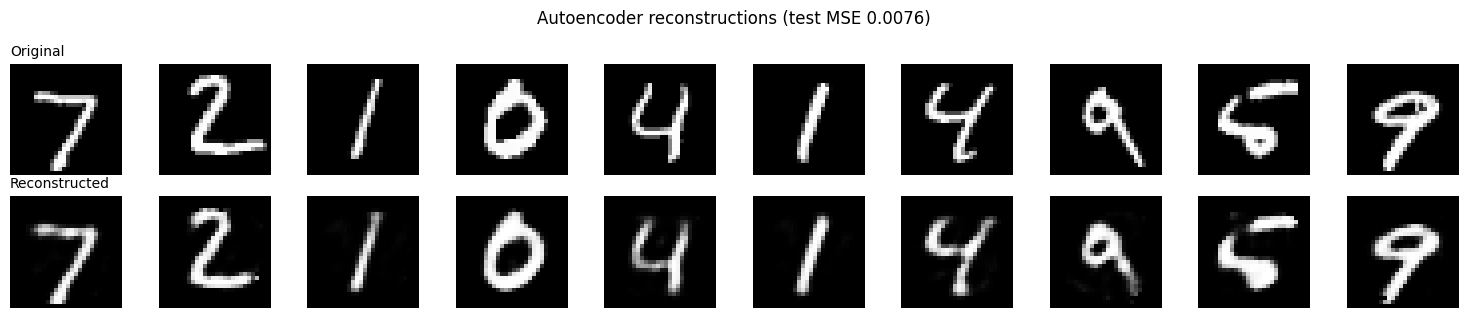

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.2))
for i in range(10):
    axes[0, i].imshow(r['ae_originals'][i], cmap='gray'); axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original', fontsize=10, loc='left')
    axes[1, i].imshow(r['ae_reconstructed'][i], cmap='gray'); axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title('Reconstructed', fontsize=10, loc='left')
plt.suptitle(f"Autoencoder reconstructions (test MSE {r['ae_mse']:.4f})")
plt.tight_layout()
plt.show()

## 3. The GAN

Generator: `100 -> 128 -> 784` (sigmoid output). Discriminator: `784 -> 128 -> 1` (sigmoid). Adversarial training: per step, train D on a half-batch of real and a half-batch of fake images, then train G (via the stacked GAN with D frozen) to fool D into outputting 1 on the fakes.

In [5]:
def build_generator():
    return models.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(784, activation='sigmoid'),
    ], name='generator')

def build_discriminator():
    return models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ], name='discriminator')

g = build_generator()
d = build_discriminator()
g.summary(); d.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,064 (445.56 KB)

 Trainable params: 114,064 (445.56 KB)

 Non-trainable params: 0 (0.00 B)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

### GAN results

Discriminator accuracy on a fresh batch of real test images vs freshly-generated fakes. With a healthy adversarial equilibrium both would sit near 50% (D can't tell them apart). With a small FC architecture and 5,000 epochs we end up well above that on real, below on fake - the discriminator wins.

In [6]:
print(f"GAN training time: {r['gan_seconds']:.1f}s")
print(f"Discriminator accuracy on real test images: {r['disc_final_real']*100:.1f}%")
print(f"Discriminator accuracy on fake samples:     {r['disc_final_fake']*100:.1f}%")

GAN training time: 28.7s
Discriminator accuracy on real test images: 91.5%
Discriminator accuracy on fake samples:     93.0%


### GAN training dynamics

Rolling discriminator accuracy on real vs fake, and generator loss over training. The signature of mode collapse or D-domination is D's accuracy on fake heading toward 100% and staying there - keep an eye on the orange line.

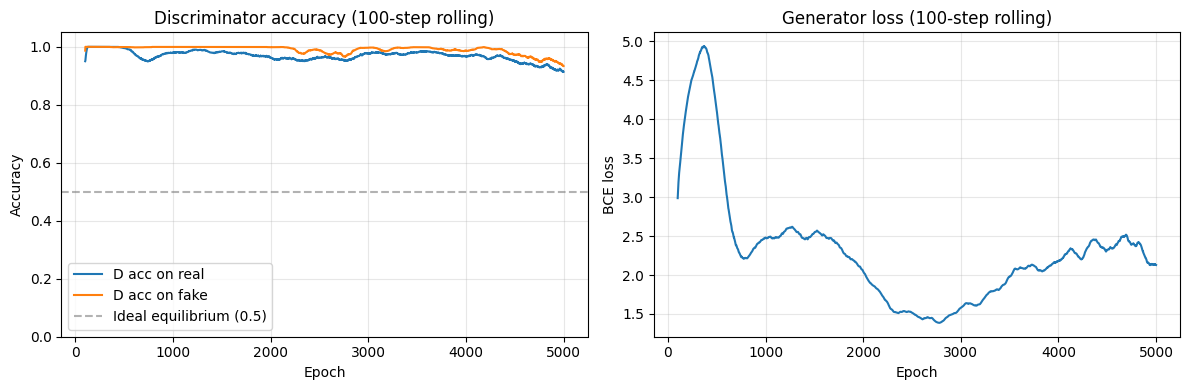

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
window = 100
real = r['disc_acc_real']
fake = r['disc_acc_fake']
loss = r['gan_losses']
real_smooth = np.convolve(real, np.ones(window)/window, mode='valid')
fake_smooth = np.convolve(fake, np.ones(window)/window, mode='valid')
loss_smooth = np.convolve(loss, np.ones(window)/window, mode='valid')

ax = axes[0]
ax.plot(np.arange(window-1, len(real)) + 1, real_smooth, label='D acc on real')
ax.plot(np.arange(window-1, len(fake)) + 1, fake_smooth, label='D acc on fake')
ax.axhline(0.5, ls='--', color='gray', alpha=0.6, label='Ideal equilibrium (0.5)')
ax.set_title(f'Discriminator accuracy ({window}-step rolling)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(np.arange(window-1, len(loss)) + 1, loss_smooth)
ax.set_title(f'Generator loss ({window}-step rolling)')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE loss')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### GAN samples across training

Same fixed noise vectors fed to the generator at four checkpoints. Each column is one noise vector; each row is one checkpoint. The early-epoch row is essentially uniform noise; the later rows show the generator gradually carving digit-shaped structure out of the noise.

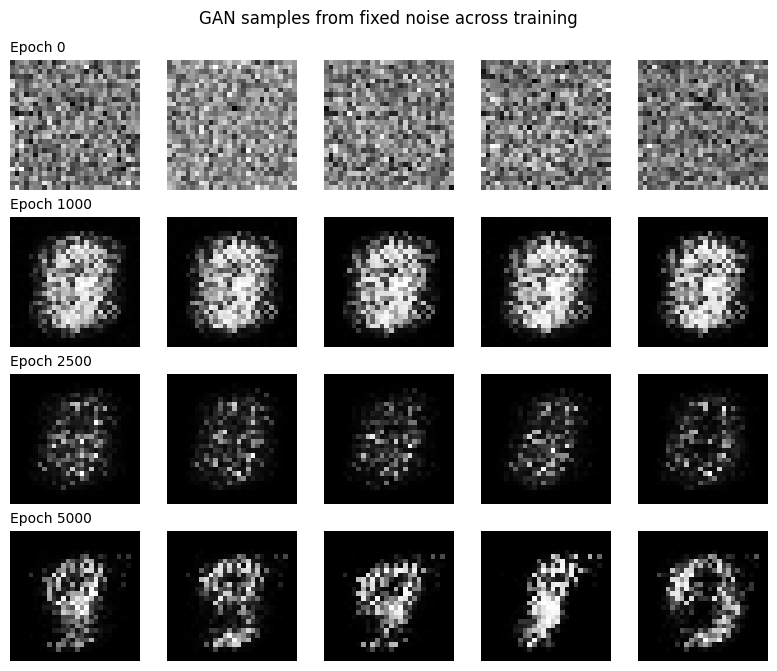

In [8]:
epochs_seen = r['gan_sample_epochs']
grids = r['gan_sample_grids']  # (4, 25, 28, 28)
fig, axes = plt.subplots(len(epochs_seen), 5, figsize=(8, 1.7 * len(epochs_seen)))
for row, ep in enumerate(epochs_seen):
    grid = grids[row]
    for col in range(5):
        ax = axes[row, col]
        ax.imshow(grid[col], cmap='gray'); ax.axis('off')
    axes[row, 0].set_title(f'Epoch {ep}', fontsize=10, loc='left')
plt.suptitle('GAN samples from fixed noise across training', fontsize=12)
plt.tight_layout()
plt.show()

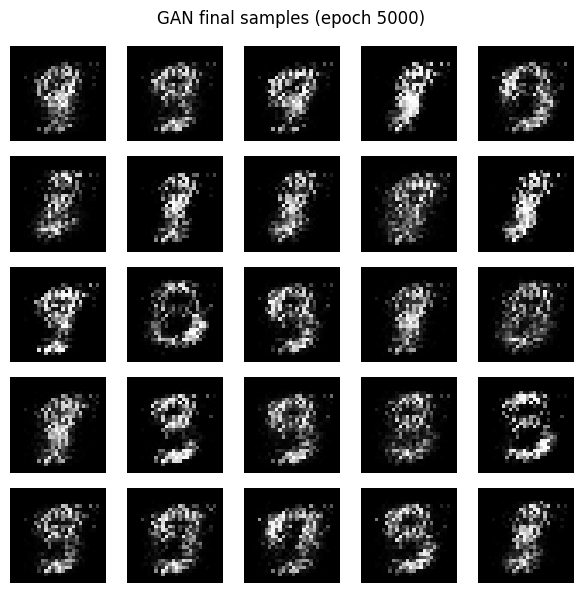

In [9]:
# Final 5x5 grid from the trained generator
final = grids[-1]
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(final[i], cmap='gray'); ax.axis('off')
plt.suptitle(f'GAN final samples (epoch {epochs_seen[-1]})', fontsize=12)
plt.tight_layout()
plt.show()

## 4. How the metrics map onto each model

**Autoencoder -> MSE is enough.** The autoencoder has a fixed ground-truth target - the input itself. MSE measures exactly what we care about: how much of the original signal the model can squeeze through the 64-d bottleneck and recover. Lower MSE = sharper reconstructions. The originals-vs-reconstructions grid is a visual sanity check, not the primary metric.

**GAN -> no ground truth, so MSE is meaningless.** There is no 'correct' image for a given noise vector, so we can't directly score the output. We get two indirect signals:

1. **Discriminator accuracy** is a proxy for sample quality. If D is stuck at ~50% on both, the samples are good enough that D can't tell them from real. If D is at ~100% on fake, the generator hasn't caught up. In our run D is winning by a comfortable margin - the FC generator can't match the FC discriminator at this scale.
2. **Visual inspection.** This is still the most reliable metric for small GAN runs. Production work uses FID or Inception Score, but for a tutorial GAN, eyeballing the samples is the honest answer.

**The bigger picture.** Autoencoders are evaluated against a well-defined target; GANs are evaluated against a moving definition of 'realistic'. That's why GAN evaluation is famously hard, and why even production GAN papers spend pages defending whichever metric they picked.